<h1 style="font-size:48px; text-align:center;">Peaucellier-Lipkin mechanisme: analyse</h1>

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Mobiliteit van de mechanisme </h3>
De Chebychev–Grübler–Kutzbach formule voor mobiliteit in een vlak geeft: 

$$M = {\color{red}3}(n − 1) − {\color{blue}2}f_1 − f_2$$

Met:

$n = 10$

$f_1 = 13 $

$f_2 = 0 $

Wat geeft $M = 1$


</div> 

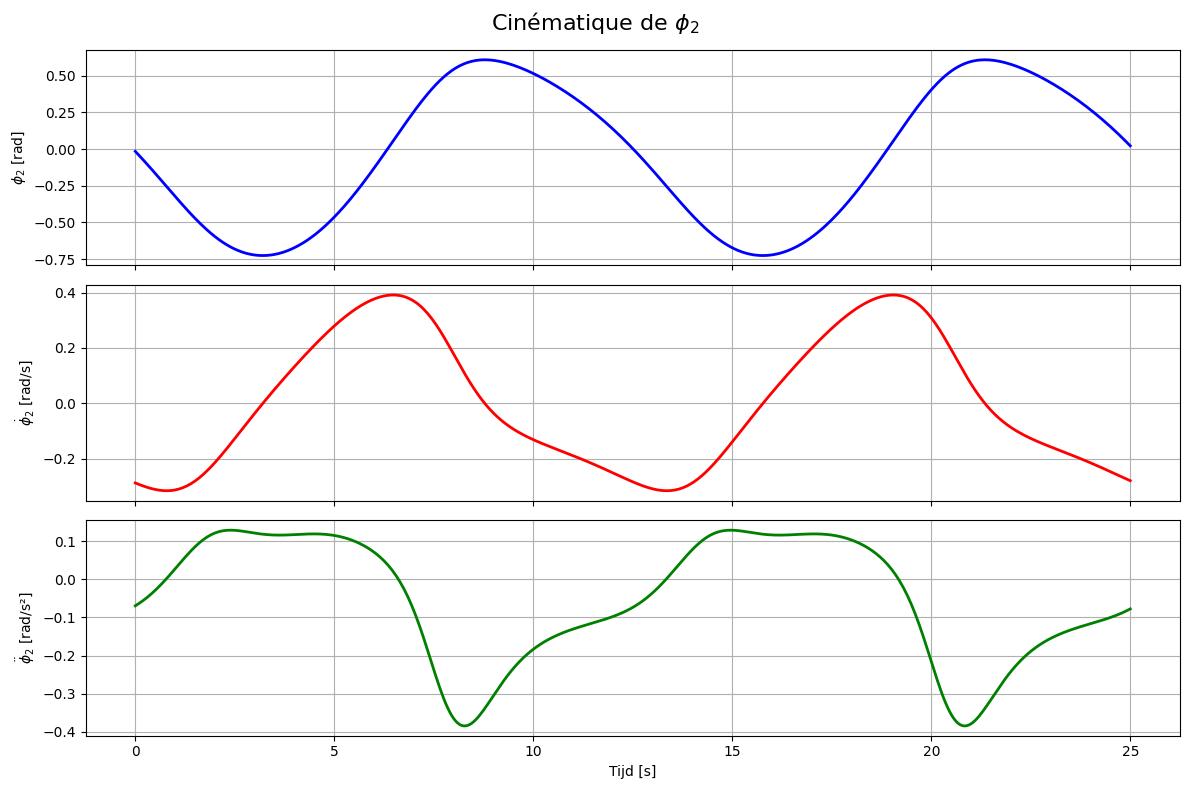

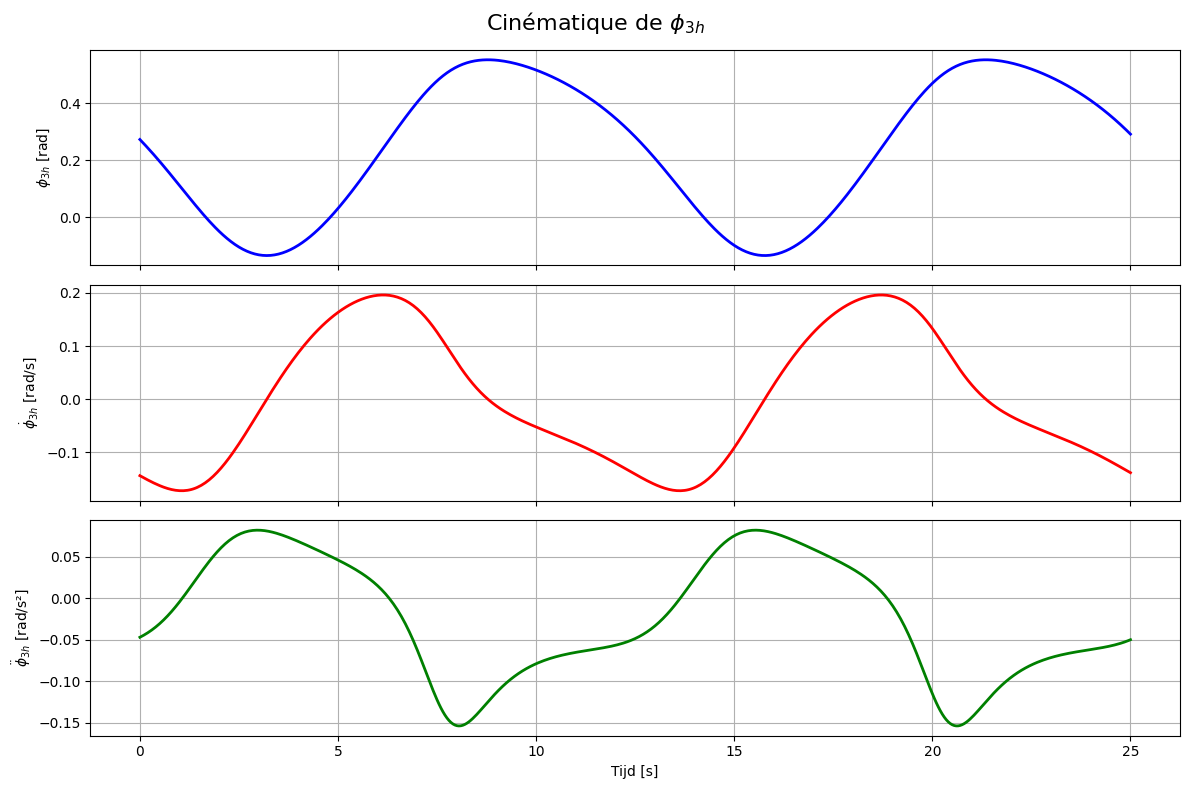

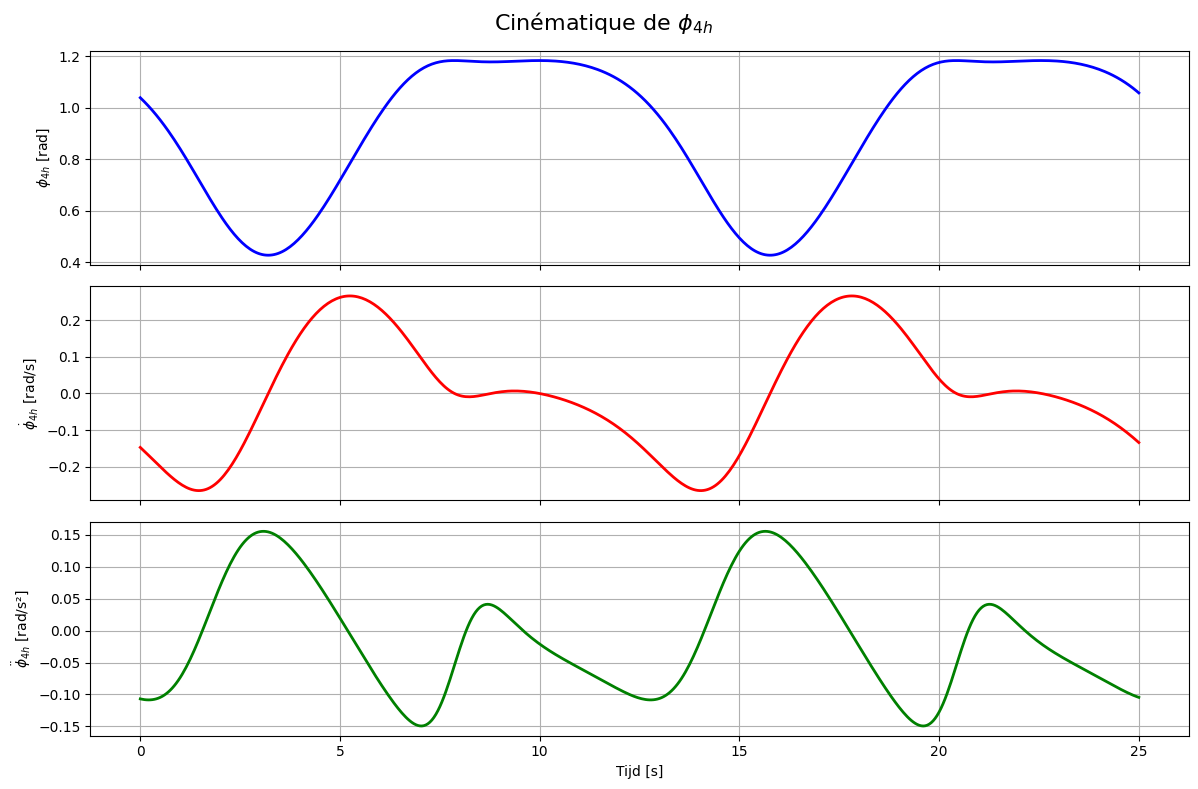

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# geometrische parameters

r2  = 0.15
r1  = 0.15
r5l = 0.12
r5h = 0.12
r4l = 0.12
r4h = 0.12

phi2_init  = 0.0
phi4h_init =  math.pi/3
phi4l_init = -math.pi/3

r3l = math.sqrt((r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init))**2 +
                (      r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init))**2)

r3h = math.sqrt((r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init))**2 +
                (      r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init))**2)

r3h_ext = r3h

phi3h_init = math.atan2((r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init)),
                        (r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init)))

phi3l_init = math.atan2((r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init)),
                        (r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init)))

# Crank-slider
r_crank  = 0.12
L_bielle = 0.25
F = np.array([-0.36, -0.32])

# tijd en driver definitie

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

omega_crank = 0.5
theta_crank = omega_crank * t

# Rotatie van vector

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z


# Sluitingsvergelijkingen

def system_equations(x, theta_k):
    phi2, phi3h, phi4h, phi3l, phi4l = x

    # high lus
    F1 = r1 + r2*np.cos(phi2) + r4h*np.cos(phi4h) - r3h*np.cos(phi3h)
    F2 =      r2*np.sin(phi2) + r4h*np.sin(phi4h) - r3h*np.sin(phi3h)

    # low lus
    F3 = r1 + r2*np.cos(phi2) + r4l*np.cos(phi4l) - r3l*np.cos(phi3l)
    F4 =      r2*np.sin(phi2) + r4l*np.sin(phi4l) - r3l*np.sin(phi3l)

    # Extentie van r3h + crank-slider
    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h + np.pi)
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    F5 = (E[0] - Q[0])**2 + (E[1] - Q[1])**2 - L_bielle**2

    return [F1, F2, F3, F4, F5]


# kinematische resolutie

phi2  = np.zeros_like(t)
phi3h = np.zeros_like(t)
phi4h = np.zeros_like(t)
phi3l = np.zeros_like(t)
phi4l = np.zeros_like(t)

dphi2  = np.zeros_like(t)
dphi3h = np.zeros_like(t)
dphi4h = np.zeros_like(t)
dphi3l = np.zeros_like(t)
dphi4l = np.zeros_like(t)

ddphi2  = np.zeros_like(t)
ddphi3h = np.zeros_like(t)
ddphi4h = np.zeros_like(t)
ddphi3l = np.zeros_like(t)
ddphi4l = np.zeros_like(t)

x_guess = np.array([phi2_init, phi3h_init, phi4h_init, phi3l_init, phi4l_init])

for k in range(len(t)):
    
    # ============================
    # Hoeken
    # ============================

    theta_k = theta_crank[k]

    sol = fsolve(lambda x: system_equations(x, theta_k), x_guess)

    phi2[k], phi3h[k], phi4h[k], phi3l[k], phi4l[k] = sol

    x_guess = sol

    phi2_k, phi3h_k, phi4h_k, phi3l_k, phi4l_k = sol

    # ============================
    # Hoeksnelheden
    # ============================

    A = np.zeros((5,5))

    # F1
    A[0,0] = -r2*np.sin(phi2_k)
    A[0,1] =  r3h*np.sin(phi3h_k)
    A[0,2] = -r4h*np.sin(phi4h_k)

    # F2
    A[1,0] =  r2*np.cos(phi2_k)
    A[1,1] = -r3h*np.cos(phi3h_k)
    A[1,2] =  r4h*np.cos(phi4h_k)

    # F3
    A[2,0] = -r2*np.sin(phi2_k)
    A[2,3] =  r3l*np.sin(phi3l_k)
    A[2,4] = -r4l*np.sin(phi4l_k)

    # F4
    A[3,0] =  r2*np.cos(phi2_k)
    A[3,3] = -r3l*np.cos(phi3l_k)
    A[3,4] =  r4l*np.cos(phi4l_k)

    C = np.array([0.0, 0.0])

    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + np.pi)
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    dE_dphi3h = rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + 3*np.pi/2)

    A[4,1] = 2*(E[0]-Q[0])*dE_dphi3h[0] \
           + 2*(E[1]-Q[1])*dE_dphi3h[1]

    B = np.zeros(5)

    dQ_dtheta = rotate_vector(np.array([r_crank, 0.0]), theta_k + np.pi/2)

    B[4] = 2*(E[0]-Q[0])*dQ_dtheta[0]*omega_crank \
         + 2*(E[1]-Q[1])*dQ_dtheta[1]*omega_crank

    dphi = np.linalg.solve(A, B)

    dphi2[k]  = dphi[0]
    dphi3h[k] = dphi[1]
    dphi4h[k] = dphi[2]
    dphi3l[k] = dphi[3]
    dphi4l[k] = dphi[4]

    # ============================
    # Hoekversnellingen
    # ============================

    dotA = np.zeros((5,5))

    # ligne 1
    dotA[0,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[0,1] =  r3h*np.cos(phi3h_k) * dphi3h[k]
    dotA[0,2] = -r4h*np.cos(phi4h_k) * dphi4h[k]

    # ligne 2
    dotA[1,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[1,1] =  r3h*np.sin(phi3h_k) * dphi3h[k]
    dotA[1,2] = -r4h*np.sin(phi4h_k) * dphi4h[k]

    # ligne 3
    dotA[2,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[2,3] =  r3l*np.cos(phi3l_k) * dphi3l[k]
    dotA[2,4] = -r4l*np.cos(phi4l_k) * dphi4l[k]

    # ligne 4
    dotA[3,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[3,3] =  r3l*np.sin(phi3l_k) * dphi3l[k]
    dotA[3,4] = -r4l*np.sin(phi4l_k) * dphi4l[k]

    # ligne 5
    d2E_dphi3h2 = rotate_vector(np.array([r3h_ext,0]), phi3h_k)

    dotA[4,1] = 2*(dE_dphi3h @ dE_dphi3h)*dphi3h[k] \
              + 2*((E-Q) @ d2E_dphi3h2)*dphi3h[k]

    # 
    # dotB
    # 

    dotB = np.zeros(5)

    d2Q_dtheta2 = -rotate_vector(np.array([r_crank,0]), theta_k)

    dotB[4] = 2*((E-Q) @ d2Q_dtheta2) * omega_crank**2 \
            + 2*(dE_dphi3h @ dQ_dtheta) * dphi3h[k] * omega_crank

    rhs = dotB - dotA @ dphi

    ddphi = np.linalg.solve(A, rhs)

    ddphi2[k]  = ddphi[0]
    ddphi3h[k] = ddphi[1]
    ddphi4h[k] = ddphi[2]
    ddphi3l[k] = ddphi[3]
    ddphi4l[k] = ddphi[4]


# ==========================================================
# ANIMATIE
# ==========================================================

x_left   = -0.55
x_right  =  0.50
y_bottom = -0.50
y_top    =  0.30

C = np.array([0.0, 0.0])

plt.ioff()

fig, ax = plt.subplots()

t_size = len(t)

frames = t_size / 5

delta = int(np.floor(t_size / frames))

index_vec = np.arange(0, t_size, delta, dtype=int)


def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()

    ax.set_aspect('equal', adjustable='box')   # Tegen WARNING meldingen

    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)

    ax.set_title(f'Frame {k}')

    # Base : C -> A -> B
    A = C + np.array([r1, 0.0])
    B = A + rotate_vector(np.array([r2, 0.0]), phi2[k])

    # High / low branch
    D_h = B + rotate_vector(np.array([r4h, 0.0]), phi4h[k])
    D_l = B + rotate_vector(np.array([r4l, 0.0]), phi4l[k])

    P = D_h + (D_l - B)

    loop_ground  = np.array([C, A, B])
    loop_rhombus = np.array([B, D_h, P, D_l, B])

    loop_r3h = np.array([C, D_h])
    loop_r3l = np.array([C, D_l])

    ax.plot(loop_ground[:,0], loop_ground[:,1], '-o')

    ax.plot(loop_rhombus[:,0], loop_rhombus[:,1], '-o')

    ax.plot(loop_r3h[:,0], loop_r3h[:,1],
            '-o', color='purple', linewidth=2)

    ax.plot(loop_r3l[:,0], loop_r3l[:,1],
            '-o', color='green', linewidth=2)

    # verticale stippellijn
    xP = P[0]

    ax.plot([xP, xP],
            [y_bottom, y_top],
            '--',
            color='lightgray',
            linewidth=1)

    # Extensie
    E = C + rotate_vector(np.array([r3h_ext, 0.0]),
                          phi3h[k] + np.pi)

    ax.plot([C[0], E[0]],
            [C[1], E[1]],
            '-o',
            color='purple',
            linewidth=2)

    # Crank-slider
    Q = F + rotate_vector(np.array([r_crank, 0.0]),
                          theta_crank[k])

    ax.plot([F[0], Q[0]],
            [F[1], Q[1]],
            '-o',
            color='green',
            linewidth=2)

    ax.plot([Q[0], E[0]],
            [Q[1], E[1]],
            '-o',
            color='green',
            linewidth=2)

    return []


ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)   # vermijdt parasitaire frames

display(HTML(ani.to_jshtml()))

# ==========================================================
# GRAFIEKEN PHI2
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi2, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_2$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi2, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_2$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi2, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_2$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_2$', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIEKEN PHI3H
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi3h, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_{3h}$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi3h, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_{3h}$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi3h, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_{3h}$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_{3h}$', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIEKEN PHI4H
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi4h, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_{4h}$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi4h, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_{4h}$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi4h, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_{4h}$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_{4h}$', fontsize=16)
plt.tight_layout()
plt.show()


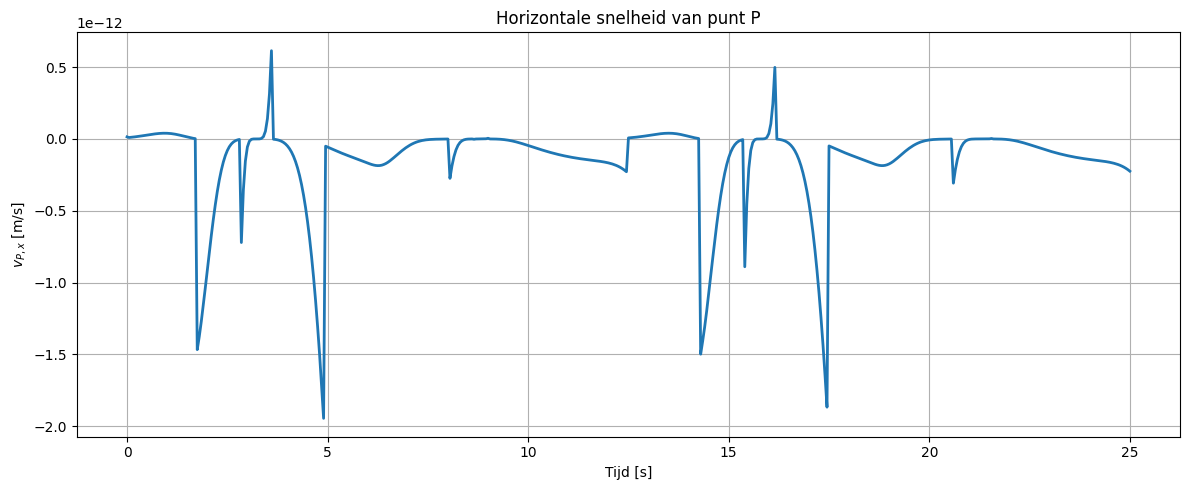

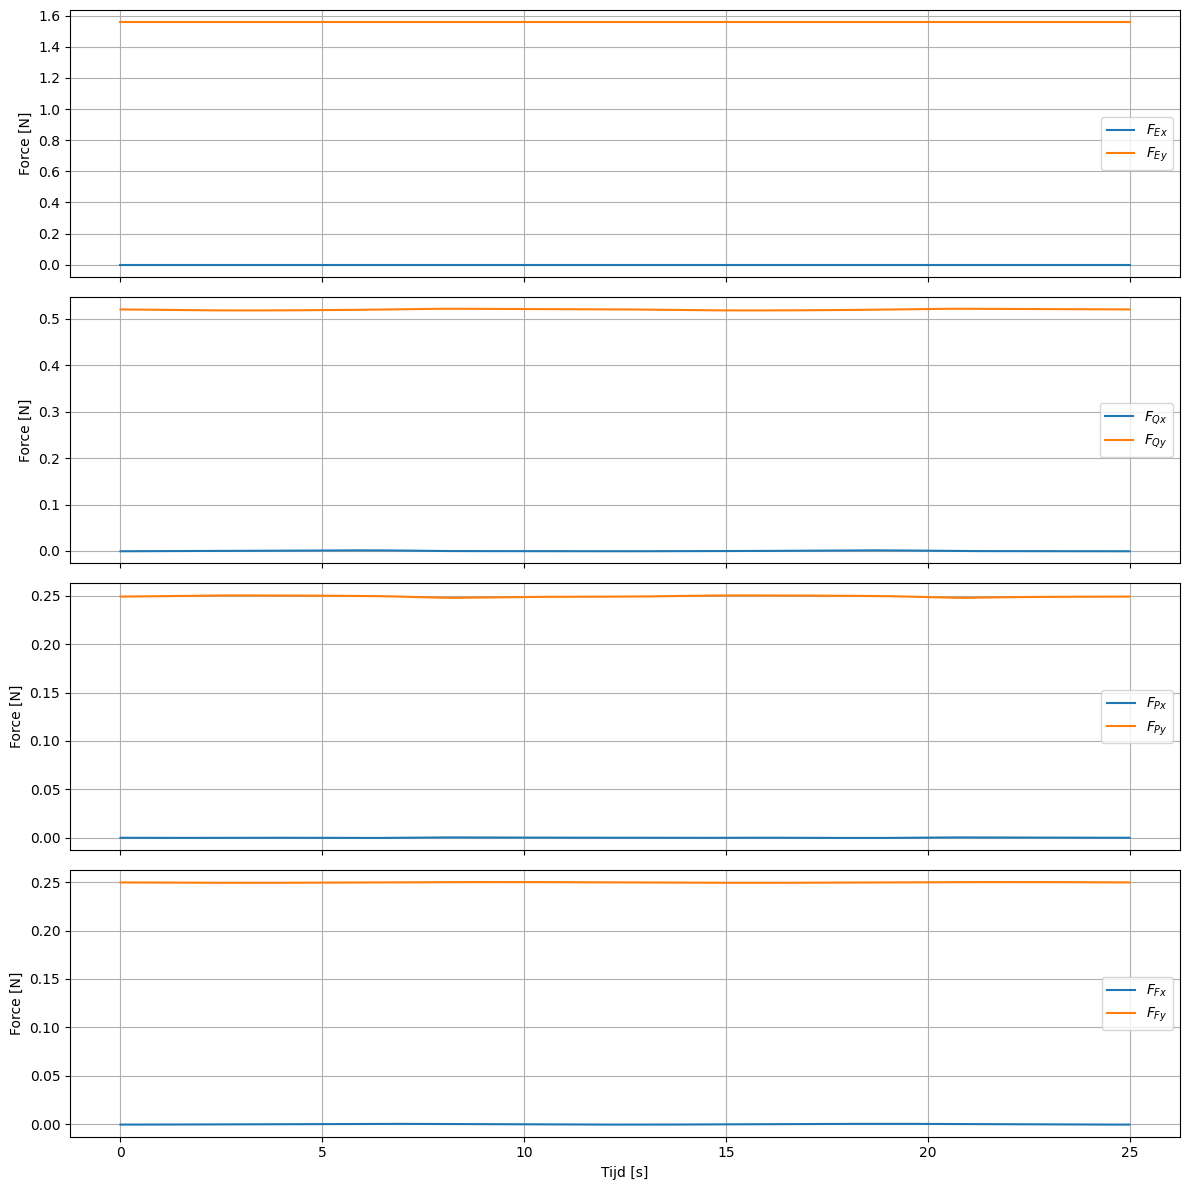

In [25]:
# ==========================================================
# DYNAMIQUE DU MÉCANISME
# ==========================================================

# ----------------------------------------------------------
# OUTILS CINÉMATIQUES
# ----------------------------------------------------------

def next_joint_vel(vA, r, phi, dphi):

    vx = vA[0] - r*np.sin(phi)*dphi
    vy = vA[1] + r*np.cos(phi)*dphi

    return np.array([vx, vy])


def next_joint_acc(aA, r, phi, dphi, ddphi):

    ax = aA[0] - r*np.cos(phi)*dphi**2 - r*np.sin(phi)*ddphi
    ay = aA[1] - r*np.sin(phi)*dphi**2 + r*np.cos(phi)*ddphi

    return np.array([ax, ay])


def cog_kinematics(valA, valB, Cog_parameter):

    return valA * (1 - Cog_parameter) + valB * Cog_parameter


# ----------------------------------------------------------
# CLASSE BARRE
# ----------------------------------------------------------

class BarLink:

    def __init__(self,
                 density,
                 diameter,
                 length,
                 vBegin,
                 vEnd,
                 aBegin,
                 aEnd,
                 Cog_parameter,
                 angular_velocity=None,
                 angular_acceleration=None):

        self.density = density
        self.diameter = diameter
        self.length = length

        self.angular_velocity = angular_velocity
        self.angular_acceleration = angular_acceleration

        self.Cog_parameter = Cog_parameter

        self.velocity = cog_kinematics(
            vBegin,
            vEnd,
            self.Cog_parameter
        )

        self.acceleration = cog_kinematics(
            aBegin,
            aEnd,
            self.Cog_parameter
        )

    @property
    def cross_sectional_area(self):

        radius = self.diameter / 2

        return np.pi * radius**2

    @property
    def volume(self):

        return self.cross_sectional_area * self.length

    @property
    def mass(self):

        return self.density * self.volume

    @property
    def inertia(self):

        return (1/12) * self.mass * self.length**2

    def distance_Cog_joint(self, joint_number):

        if joint_number == 1:
            return self.Cog_parameter * self.length

        elif joint_number == 2:
            return self.length - self.Cog_parameter * self.length


# ==========================================================
# CINÉMATIQUE DES POINTS
# ==========================================================

N = len(t)

# point fixe
vC = np.zeros((2, N))
aC = np.zeros((2, N))

# point A
vA = np.zeros((2, N))
aA = np.zeros((2, N))

# point B
vB = next_joint_vel(vA, r2, phi2, dphi2)
aB = next_joint_acc(aA, r2, phi2, dphi2, ddphi2)

# branche haute : D_h
vDh = next_joint_vel(vB, r4h, phi4h, dphi4h)
aDh = next_joint_acc(aB, r4h, phi4h, dphi4h, ddphi4h)

# branche basse : D_l
vDl = next_joint_vel(vB, r4l, phi4l, dphi4l)
aDl = next_joint_acc(aB, r4l, phi4l, dphi4l, ddphi4l)

# punt P
# géométrie :
# P = D_h + (D_l - B)

P_x = np.zeros(N)
P_y = np.zeros(N)

vP = np.zeros((2, N))
aP = np.zeros((2, N))

for k in range(N):

    # coordinaten van de punten
    Bk = np.array([
        r1 + r2*np.cos(phi2[k]),
        r2*np.sin(phi2[k])
    ])

    Dhk = np.array([
        r3h*np.cos(phi3h[k]),
        r3h*np.sin(phi3h[k])
    ])

    Dlk = np.array([
        r3l*np.cos(phi3l[k]),
        r3l*np.sin(phi3l[k])
    ])

    # point P du parallélogramme
    Pk = Dhk + (Dlk - Bk)

    P_x[k] = Pk[0]
    P_y[k] = Pk[1]

    # vitesse :
    # vP = vDh + (vDl - vB)

    vP[:,k] = vDh[:,k] + (vDl[:,k] - vB[:,k])

    # accélération
    aP[:,k] = aDh[:,k] + (aDl[:,k] - aB[:,k])

# =============================================================
# Check: plot horizontale snelheid van punt P => Moet nul zijn
# =============================================================

plt.figure(figsize=(12,5))

plt.plot(t, vP[0], linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$v_{P,x}$ [m/s]')

plt.title('Horizontale snelheid van punt P')

plt.grid(True)

plt.tight_layout()

plt.show()

# ==============================================================

# extension E
vE = next_joint_vel(vC, r3h_ext, phi3h + np.pi, dphi3h)
aE = next_joint_acc(aC, r3h_ext, phi3h + np.pi, dphi3h, ddphi3h)

# crank point Q
vQ = np.array([
    -r_crank*np.sin(theta_crank)*omega_crank,
     r_crank*np.cos(theta_crank)*omega_crank
])

aQ = np.array([
    -r_crank*np.cos(theta_crank)*omega_crank**2,
    -r_crank*np.sin(theta_crank)*omega_crank**2
])

# Fixed point F
vF_fixed = np.zeros((2, N))
aF_fixed = np.zeros((2, N))

# ==========================================================
# PROPRIÉTÉS MATÉRIAU
# ==========================================================

densityAL = 2700
diameter = 0.01
g = 9.81

Cog_parameter = 0.5

# ==========================================================
# BARRES
# ==========================================================

bar_AB = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r2,
    vBegin=vA,
    vEnd=vB,
    aBegin=aA,
    aEnd=aB,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi2,
    angular_acceleration=ddphi2
)

bar_BDh = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4h,
    vBegin=vB,
    vEnd=vDh,
    aBegin=aB,
    aEnd=aDh,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4h,
    angular_acceleration=ddphi4h
)

bar_CDl = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r3l,
    vBegin=vC,
    vEnd=vDl,
    aBegin=aC,
    aEnd=aDl,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi3l,
    angular_acceleration=ddphi3l
)

bar_BDl = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4l,
    vBegin=vB,
    vEnd=vDl,
    aBegin=aB,
    aEnd=aDl,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4l,
    angular_acceleration=ddphi4l
)

bar_DhP = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4l,
    vBegin=vDh,
    vEnd=vP,
    aBegin=aDh,
    aEnd=aP,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4l,
    angular_acceleration=ddphi4l
)

bar_DlP = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4h,
    vBegin=vDl,
    vEnd=vP,
    aBegin=aDl,
    aEnd=aP,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4h,
    angular_acceleration=ddphi4h
)

bar_EDh = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r3h + r3h_ext,
    vBegin=vE,
    vEnd=vDh,
    aBegin=aE,
    aEnd=aDh,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi3h,
    angular_acceleration=ddphi3h
)

bar_QE = BarLink(
    density=densityAL,
    diameter=diameter,
    length=L_bielle,
    vBegin=vQ,
    vEnd=vE,
    aBegin=aQ,
    aEnd=aE,
    Cog_parameter=Cog_parameter
)

bar_FQ = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r_crank,
    vBegin=vF_fixed,
    vEnd=vQ,
    aBegin=aF_fixed,
    aEnd=aQ,
    Cog_parameter=Cog_parameter,
    angular_velocity=np.ones(N)*omega_crank,
    angular_acceleration=np.zeros(N)
)

# ==========================================================
# FORCES AUX JOINTS
# ==========================================================

F_A_x = np.zeros(N)
F_A_y = np.zeros(N)

F_B_x = np.zeros(N)
F_B_y = np.zeros(N)

F_C_x = np.zeros(N)
F_C_y = np.zeros(N)

F_Dh_x = np.zeros(N)
F_Dh_y = np.zeros(N)

F_Dl_x = np.zeros(N)
F_Dl_y = np.zeros(N)

F_P_x = np.zeros(N)
F_P_y = np.zeros(N)

F_E_x = np.zeros(N)
F_E_y = np.zeros(N)

F_Q_x = np.zeros(N)
F_Q_y = np.zeros(N)

F_F_x = np.zeros(N)
F_F_y = np.zeros(N)

# ==========================================================
# RÉSOLUTION DYNAMIQUE CORRIGÉE
# ==========================================================

for k in range(N):

    # ------------------------------------------------------
    # MATRICE
    # ------------------------------------------------------

    A_dyn = np.eye(18)

    # ------------------------------------------------------
    # SECOND MEMBRE
    # ------------------------------------------------------

    B_dyn = np.array([

        # AB
        bar_AB.mass * bar_AB.acceleration[0][k],
        bar_AB.mass * bar_AB.acceleration[1][k]
        + bar_AB.mass * g,

        # ED_h
        bar_EDh.mass * bar_EDh.acceleration[0][k],
        bar_EDh.mass * bar_EDh.acceleration[1][k]
        + bar_EDh.mass * g,

        # BD_h
        bar_BDh.mass * bar_BDh.acceleration[0][k],
        bar_BDh.mass * bar_BDh.acceleration[1][k]
        + bar_BDh.mass * g,

        # CD_l
        bar_CDl.mass * bar_CDl.acceleration[0][k],
        bar_CDl.mass * bar_CDl.acceleration[1][k]
        + bar_CDl.mass * g,

        # BD_l
        bar_BDl.mass * bar_BDl.acceleration[0][k],
        bar_BDl.mass * bar_BDl.acceleration[1][k]
        + bar_BDl.mass * g,

        # QE
        bar_QE.mass * bar_QE.acceleration[0][k],
        bar_QE.mass * bar_QE.acceleration[1][k]
        + bar_QE.mass * g,

        # FQ
        bar_FQ.mass * bar_FQ.acceleration[0][k],
        bar_FQ.mass * bar_FQ.acceleration[1][k]
        + bar_FQ.mass * g,

        # D_hP
        bar_DhP.mass * bar_DhP.acceleration[0][k],
        bar_DhP.mass * bar_DhP.acceleration[1][k]
        + bar_DhP.mass * g,

        # D_lP
        bar_DlP.mass * bar_DlP.acceleration[0][k],
        bar_DlP.mass * bar_DlP.acceleration[1][k]
        + bar_DlP.mass * g

    ])

    # ------------------------------------------------------
    # SOLUTION
    # ------------------------------------------------------

    x_dyn = np.linalg.solve(A_dyn, B_dyn)

    F_A_x[k]  = x_dyn[0]
    F_A_y[k]  = x_dyn[1]

    F_E_x[k]  = x_dyn[2]
    F_E_y[k]  = x_dyn[3]

    F_Dh_x[k] = x_dyn[4]
    F_Dh_y[k] = x_dyn[5]

    F_C_x[k]  = x_dyn[6]
    F_C_y[k]  = x_dyn[7]

    F_Dl_x[k] = x_dyn[8]
    F_Dl_y[k] = x_dyn[9]

    F_Q_x[k]  = x_dyn[10]
    F_Q_y[k]  = x_dyn[11]

    F_F_x[k]  = x_dyn[12]
    F_F_y[k]  = x_dyn[13]

    F_P_x[k]  = x_dyn[14]
    F_P_y[k]  = x_dyn[15]

# ==========================================================
# AFFICHAGE DES FORCES PRINCIPALES
# ==========================================================

fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# ----------------------------------------------------------
# FORCE AU POINT E
# ----------------------------------------------------------

axs[0].plot(t, F_E_x, label=r'$F_{Ex}$')
axs[0].plot(t, F_E_y, label=r'$F_{Ey}$')

axs[0].set_ylabel('Force [N]')

axs[0].grid(True)
axs[0].legend()

# ----------------------------------------------------------
# FORCE AU POINT Q
# ----------------------------------------------------------

axs[1].plot(t, F_Q_x, label=r'$F_{Qx}$')
axs[1].plot(t, F_Q_y, label=r'$F_{Qy}$')

axs[1].set_ylabel('Force [N]')

axs[1].grid(True)
axs[1].legend()

# ----------------------------------------------------------
# FORCE AU POINT P
# ----------------------------------------------------------

axs[2].plot(t, F_P_x, label=r'$F_{Px}$')
axs[2].plot(t, F_P_y, label=r'$F_{Py}$')

axs[2].set_ylabel('Force [N]')

axs[2].grid(True)
axs[2].legend()

# ----------------------------------------------------------
# FORCE AU POINT F
# ----------------------------------------------------------

axs[3].plot(t, F_F_x, label=r'$F_{Fx}$')
axs[3].plot(t, F_F_y, label=r'$F_{Fy}$')

axs[3].set_xlabel('Tijd [s]')
axs[3].set_ylabel('Force [N]')

axs[3].grid(True)
axs[3].legend()

plt.tight_layout()

plt.show()